Este cuaderno, tiene el fin de presentar una metodología de calculo para diseñar un inductor para el circuito sintonizado. Para ello, se nos presentan las siguientes especificaciones:
 * Frecuencia de Resonancia $f_{o} = 18 [MHz]$
 * Impedancia de Entrada: $Z_{in} = 50 [\Omega]$
 * Impedancia de Salida: $Z_{o} = 1 [k\Omega]$
 * Factor de Calidad: $Q_{c} = 10 [%]$

De estas especificaciones, determinaremos las características físicas del inductor, tales como:
 * Numero de Espiras ($N$).
 * Longitud del Conductor ($l$).
 * Diametro del Conductor ($D$).
 * Relación de Aspecto ($\frac{l}{D}$).
 * Separación entre Espiras ($S$).

Consecuentemente, tendremos los parámetros de salida y caracteristicas circuitales del inductor, siendo estas:
 * Inductacia ($L$).
 * Factor de Calidad Descargado o del inductor ($Q_{D}$).
 * Resistencia de Pérdida ($R_{P}$).

Finalmente, sabiendo estos valores, podemos plantear un sistema de ecuaciones donde sabiendo el valor de $L$ y de $f_{o}$, despejaremos los valores de los capacitores: $C_{1}$, $C_{2}$, $C_{3}$ y $C_{4}$.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from scipy.optimize import fsolve
from scipy.optimize import least_squares

## 1- Defino la frecuencia de resonancia
f_o_mhz = 18                  # Especificación de frecuencia. 
f_o = f_o_mhz * 1e6           # Conversión a [Hz].
BW = f_o_mhz * 0.1            # Definición del ancho de banda (BW) en [MHz].



## 2- Defino los posibles parámetros físicos del Inductor
# 2.1- Se realizo un arreglo con los valores posibles de los Diametros de cobre esmaltados (d) para su posterior análisis (0.15 - 0.30)cm.
Diametros_cm = np.zeros(16)
for i in range(16):
    Diametros_cm[i] = 0.15+(i*0.01)
print()
print(f"Diametros (d): {Diametros_cm} cm")
print()

# 2.2- Para facilitar la construcción del inductor, se utilizó una separación entre espiras (S) del mismo tamaño que el Diametro del Conductor (D):
Se_cm = np.zeros(16)
for i in range(16):
    Se_cm[i] = Diametros_cm[i]
print(f"Separación entre espiras (S): {Se_cm} cm")
print()

# 2.3- Para realizar el inductor, se propone usar algún objeto lo más cilíndrico posible. Se elige el valor de 2.2 [cm] obtenido de un Slide de Guitarra:
# Vease: https://es.wikipedia.org/wiki/Slide_(guitarra)
Do_cm = 3.48
print(Do_cm)

# 2.4- Creo un vector con los posibles diámetros totales:
Dtotal_cm = np.zeros(16)
for i in range(16):
  Dtotal_cm[i]= Do_cm + 2* Diametros_cm[i]
print(f"Diámetro total del inductor (D_t): {Dtotal_cm} [cm]")
print()

# 2.5- Dado que se busca diseñar un inductor lo mas cuadrada posible, se plantea una relación de aspecto: l/d entre 1 y 2:
RelacionLD = np.zeros(11)
for i in range(11):
  RelacionLD[i] = 1 + i*0.1
print(f"Relaciones Diámetro-Largo (l/D): {RelacionLD} ")
print()

# 2.6- Dado que habrán 16 diámetros de cable posibles y con cada diámetro vamos a tener 11 opciones de largos para cada diámetro.
Largo_cm = np.zeros((11,16))                    # Array con los posibles largos (l).
for i in range(11):
  for j in range(16):
    Largo_cm[i,j] = Dtotal_cm[j] * RelacionLD[i]

N = np.zeros((11,16))                           # Array con número de espiras posibles (N).
for i in range(11):
  for j in range(16):
    N[i,j] = Largo_cm[i,j]/(2*Diametros_cm[j])



## 3- Tablas de parámetros
# 3.1- Se crearon las etiquetas para las filas y columnas y se usaron los valores reales, para que la tabla sea fácil de leer.
filas_relacion = [f"L/D={r:.1f}" for r in RelacionLD]
columnas_diams = [f"D_cu={d:.2f}cm" for d in Diametros_cm]

# 3.2- Se convertió la matriz de Largos en una Tabla (DataFrame):
df_largos = pd.DataFrame(Largo_cm, index=filas_relacion, columns=columnas_diams)

# 3.3 Convertir la matriz de Espiras (N) en una Tabla:
df_espiras = pd.DataFrame(N, index=filas_relacion, columns=columnas_diams)

# 3.4- Se muestran las tablas:
print("Tabla de Largos del Inductor [cm]")
display(df_largos)

print("\n Tabla del Número de Espiras (N)")
display(df_espiras)


Diametros (d): [0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27 0.28
 0.29 0.3 ] cm

Separación entre espiras (S): [0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27 0.28
 0.29 0.3 ] cm

3.48
Diámetro total del inductor (D_t): [3.78 3.8  3.82 3.84 3.86 3.88 3.9  3.92 3.94 3.96 3.98 4.   4.02 4.04
 4.06 4.08] [cm]

Relaciones Diámetro-Largo (l/D): [1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2. ] 

Tabla de Largos del Inductor [cm]


,D_cu=0.15cm,D_cu=0.16cm,D_cu=0.17cm,D_cu=0.18cm,D_cu=0.19cm,D_cu=0.20cm,D_cu=0.21cm,D_cu=0.22cm,D_cu=0.23cm,D_cu=0.24cm,D_cu=0.25cm,D_cu=0.26cm,D_cu=0.27cm,D_cu=0.28cm,D_cu=0.29cm,D_cu=0.30cm
L/D=1.0,3.780,3.80,3.820,3.840,3.860,3.880,3.90,3.920,3.940,3.960,3.980,4.0,4.020,4.040,4.060,4.080
L/D=1.1,4.158,4.18,4.202,4.224,4.246,4.268,4.29,4.312,4.334,4.356,4.378,4.4,4.422,4.444,4.466,4.488
L/D=1.2,4.536,4.56,4.584,4.608,4.632,4.656,4.68,4.704,4.728,4.752,4.776,4.8,4.824,4.848,4.872,4.896
L/D=1.3,4.914,4.94,4.966,4.992,5.018,5.044,5.07,5.096,5.122,5.148,5.174,5.2,5.226,5.252,5.278,5.304
L/D=1.4,5.292,5.32,5.348,5.376,5.404,5.432,5.46,5.488,5.516,5.544,5.572,5.6,5.628,5.656,5.684,5.712
L/D=1.5,5.670,5.70,5.730,5.760,5.790,5.820,5.85,5.880,5.910,5.940,5.970,6.0,6.030,6.060,6.090,6.120
L/D=1.6,6.048,6.08,6.112,6.144,6.176,6.208,6.24,6.272,6.304,6.336,6.368,6.4,6.432,6.464,6.496,6.528
L/D=1.7,6.426,6.46,6.494,6.528,6.562,6.596,6.63,6.664,6.698,6.732,6.766,6.8,6.834,6.868,6.902,6.936
L/D=1.8,6.804,6.84,6.876,6.912,6.948,6.984,7.02,7.056,7.092,7.128,7.164,7.2,7.236,7.272,7.308,7.344
L/D=1.9,7.182,7.22,7.258,7.296,7.334,7.372,7.41,7.448,7.486,7.524,7.562,7.6,7.638,7.676,7.714,7.752



 Tabla del Número de Espiras (N)


,D_cu=0.15cm,D_cu=0.16cm,D_cu=0.17cm,D_cu=0.18cm,D_cu=0.19cm,D_cu=0.20cm,D_cu=0.21cm,D_cu=0.22cm,D_cu=0.23cm,D_cu=0.24cm,D_cu=0.25cm,D_cu=0.26cm,D_cu=0.27cm,D_cu=0.28cm,D_cu=0.29cm,D_cu=0.30cm
L/D=1.0,12.60,11.8750,11.235294,10.666667,10.157895,9.70,9.285714,8.909091,8.565217,8.250,7.960,7.692308,7.444444,7.214286,7.0,6.80
L/D=1.1,13.86,13.0625,12.358824,11.733333,11.173684,10.67,10.214286,9.800000,9.421739,9.075,8.756,8.461538,8.188889,7.935714,7.7,7.48
L/D=1.2,15.12,14.2500,13.482353,12.800000,12.189474,11.64,11.142857,10.690909,10.278261,9.900,9.552,9.230769,8.933333,8.657143,8.4,8.16
L/D=1.3,16.38,15.4375,14.605882,13.866667,13.205263,12.61,12.071429,11.581818,11.134783,10.725,10.348,10.000000,9.677778,9.378571,9.1,8.84
L/D=1.4,17.64,16.6250,15.729412,14.933333,14.221053,13.58,13.000000,12.472727,11.991304,11.550,11.144,10.769231,10.422222,10.100000,9.8,9.52
L/D=1.5,18.90,17.8125,16.852941,16.000000,15.236842,14.55,13.928571,13.363636,12.847826,12.375,11.940,11.538462,11.166667,10.821429,10.5,10.20
L/D=1.6,20.16,19.0000,17.976471,17.066667,16.252632,15.52,14.857143,14.254545,13.704348,13.200,12.736,12.307692,11.911111,11.542857,11.2,10.88
L/D=1.7,21.42,20.1875,19.100000,18.133333,17.268421,16.49,15.785714,15.145455,14.560870,14.025,13.532,13.076923,12.655556,12.264286,11.9,11.56
L/D=1.8,22.68,21.3750,20.223529,19.200000,18.284211,17.46,16.714286,16.036364,15.417391,14.850,14.328,13.846154,13.400000,12.985714,12.6,12.24
L/D=1.9,23.94,22.5625,21.347059,20.266667,19.300000,18.43,17.642857,16.927273,16.273913,15.675,15.124,14.615385,14.144444,13.707143,13.3,12.92


Una vez obtenidas todas las posibles características constructivas físicas del Inductor:
 * Diametro del Cobre ($d$).
 * Diametro del Inductor ($D_{t}$).
 * Separación entre Espiras ($S$).
 * Largo del Inductor ($l$).
 * Relación de aspecto ($\frac{l}{D}$).

Podemos comenzar calculando primero el valor de inductancia del inductor, siguiendo la Fórmula de Wheeler para inductores monocapa con núcleo de aire (Véase: https://ingenio-triana.blogspot.com/2016/11/diseno-de-inductores-calculo-de-bobinas_2.html), siendo esta igual a:

$L = \frac{0,394 r^{2} N^{2}}{9r + 10l} [\mu Hy]$

Donde tanto $r$ como $l$, estarán en $[cm]$.

In [20]:
## 4- Se calcula el valor de las inductancias para cada caso siguiendo la formula de Wheeler para inductores monocapa con núcleo de aire:
# 4.1- Defino al radio del inductor como la mitad del diámetro:
r_cm = np.zeros(16)
for i in range(16):
  #r_cm[i] = Dtotal_cm[i] / 2                    # Basicamente: r = D_T/2 [cm]
  r_cm [i] = (Do_cm + Diametros_cm[i]) / 2       # Basicamente: r = D_o + d_Cu/2 [cm]

# 4.2- Calculo la inductancia con la formula previamente vista:
inductancia_uh = np.zeros((11,16))
for i in range(11):
  for j in range(16):
    inductancia_uh [i,j] = (0.394 * (r_cm[j]**2) * (N[i,j]**2)) / (9 * r_cm[j] + 10 * Largo_cm[i,j])

# 4.3- Gráfico la tabla de inductancias de acuerdo a los Diámetros del Cobre (d) y la Relación de Aspecto (l/D):
df_inductancias = pd.DataFrame(inductancia_uh, index=filas_relacion, columns=columnas_diams)
print("Tabla de Inductancias del Inductor a diseñar [uH]")
display(df_inductancias)

Tabla de Inductancias del Inductor a diseñar [uH]


,D_cu=0.15cm,D_cu=0.16cm,D_cu=0.17cm,D_cu=0.18cm,D_cu=0.19cm,D_cu=0.20cm,D_cu=0.21cm,D_cu=0.22cm,D_cu=0.23cm,D_cu=0.24cm,D_cu=0.25cm,D_cu=0.26cm,D_cu=0.27cm,D_cu=0.28cm,D_cu=0.29cm,D_cu=0.30cm
L/D=1.0,3.806383,3.384286,3.032490,2.736030,2.483739,2.267145,2.079724,1.916387,1.773114,1.646695,1.534542,1.434548,1.344985,1.264423,1.191671,1.125731
L/D=1.1,4.305116,3.827524,3.429485,3.094063,2.808621,2.563573,2.351535,2.166749,2.004664,1.861650,1.734777,1.621662,1.520348,1.429218,1.346925,1.272338
L/D=1.2,4.809535,4.275798,3.830975,3.456138,3.137160,2.863326,2.626386,2.419902,2.238788,2.078987,1.937224,1.810836,1.697637,1.595818,1.503873,1.420541
L/D=1.3,5.318654,4.728235,4.236182,3.821553,3.468720,3.165827,2.903748,2.675360,2.475038,2.298291,2.141498,2.001712,1.876515,1.763907,1.662221,1.570060
L/D=1.4,5.831704,5.184154,4.644497,4.189761,3.802805,3.470625,3.183209,2.932745,2.713063,2.519238,2.347298,2.194009,2.056721,1.933239,1.821735,1.720678
L/D=1.5,6.348075,5.643013,5.055436,4.560327,4.139023,3.777362,3.464442,3.191756,2.952588,2.741572,2.554385,2.387506,2.238047,2.103620,1.982235,1.872224
L/D=1.6,6.867276,6.104378,5.468611,4.932903,4.477057,4.085750,3.747184,3.452153,3.193389,2.965087,2.762568,2.582023,2.420327,2.274895,2.143574,2.024560
L/D=1.7,7.388909,6.567897,5.883707,5.307206,4.816653,4.395557,4.031222,3.713740,3.435286,3.189616,2.971693,2.777417,2.603425,2.446936,2.305633,2.177572
L/D=1.8,7.912647,7.033279,6.300467,5.683002,5.157599,4.706593,4.316382,3.976355,3.678133,3.415023,3.181632,2.973569,2.787232,2.619641,2.468314,2.331171
L/D=1.9,8.438220,7.500285,6.718675,6.060100,5.499722,5.018697,4.602519,4.239868,3.921805,3.641194,3.392281,3.170382,2.971655,2.792923,2.631537,2.485279


Se procede ahora, a calcular las carácterísticas físicas de un inductor dadas sus inductancias, tales como:
 * Factor de Calidad Cargado: $Q_{C} = \frac{f_{o}}{BW} = 10 \ [\%]$ 
 * Factor de Calidad Descargado: $Q_{D} = 8550 \frac{D_{t} l}{102l + 450} \sqrt{f_{o}} \ \ $ ; $ \ \ $ con f en $[MHz]$ y $D, l$ en $[cm]$
 * Resistencia de Pérdida: $R_{P} = Q_{D} X_{L} = 2 \pi f_{o} L Q_{D} [\Omega]$ 

In [21]:
## 5- Cálculo de Factores de Calidad y Resistencias de Pérdida
# 5.1- Q Cargado: Este está basado en el BW entregado como requerimiento, y como el BW es el 10% de f_o, Q_c será constante para toda la matriz:
Q_cargado = f_o / (BW * 1e6)
print(f"El factor de calidad cargado es: {Q_cargado}")
print()

# 5.2- Q Descargado: Este se estima por frecuencia y geómetria, dada la fórmula mencionada arriba:
Q_descargado = np.zeros((11, 16))
for i in range(11):
    for j in range(16):
        Q_descargado[i, j] = 8550 * ((Dtotal_cm[j]*Largo_cm[i,j])/(120*Largo_cm[i,j]+450)) * np.sqrt(f_o_mhz)

# 5.3- Resistencia de Pérdidas: Este sigue la fórmula descripta arriba:
RP = np.zeros((11, 16))
for i in range(11):
    for j in range(16):
        RP[i, j] = 2 * np.pi * f_o * (inductancia_uh[i, j] * 1e-6) * Q_descargado[i, j]                           

## 6- Generación de Tablas Finales

df_Qdescargado = pd.DataFrame(Q_descargado, index=filas_relacion, columns=columnas_diams)
df_RP = pd.DataFrame(RP, index=filas_relacion, columns=columnas_diams)


print("\nTabla del Factor de Calidad Descargado (Q_D)")
display(df_Qdescargado)

print("\nTabla de la Resistencia de Pérdida (R_P) en [Ohms]")
display(df_RP)

El factor de calidad cargado es: 10.0


Tabla del Factor de Calidad Descargado (Q_D)


,D_cu=0.15cm,D_cu=0.16cm,D_cu=0.17cm,D_cu=0.18cm,D_cu=0.19cm,D_cu=0.20cm,D_cu=0.21cm,D_cu=0.22cm,D_cu=0.23cm,D_cu=0.24cm,D_cu=0.25cm,D_cu=0.26cm,D_cu=0.27cm,D_cu=0.28cm,D_cu=0.29cm,D_cu=0.30cm
L/D=1.0,573.600795,578.151109,582.709324,587.275379,591.849212,596.430761,601.019967,605.616768,610.221107,614.832923,619.452160,624.078759,628.712664,633.353819,638.002168,642.657656
L/D=1.1,600.801136,605.491167,610.188700,614.893672,619.606022,624.325690,629.052614,633.786737,638.527999,643.276341,648.031707,652.794039,657.563282,662.339380,667.122277,671.911919
L/D=1.2,625.519766,630.330812,635.148968,639.974175,644.806371,649.645497,654.491494,659.344303,664.203865,669.070125,673.943025,678.822510,683.708524,688.601012,693.499921,698.405197
L/D=1.3,648.081508,652.998059,657.921347,662.851312,667.787894,672.731035,677.680677,682.636762,687.599234,692.568036,697.543114,702.524413,707.511879,712.505457,717.505097,722.510744
L/D=1.4,668.756866,673.765956,678.781427,683.803219,688.831277,693.865541,698.905955,703.952463,709.005011,714.063543,719.128006,724.198346,729.274511,734.356448,739.444107,744.537436
L/D=1.5,687.772928,692.863630,697.960377,703.063112,708.171777,713.286318,718.406679,723.532806,728.664644,733.802142,738.945246,744.093905,749.248068,754.407684,759.572703,764.743076
L/D=1.6,705.321737,710.484781,715.653553,720.827997,726.008060,731.193687,736.384824,741.581419,746.783419,751.990773,757.203431,762.421341,767.644455,772.872724,778.106099,783.344533
L/D=1.7,721.566802,726.794268,732.027167,737.265443,742.509044,747.757917,753.012010,758.271273,763.535655,768.805106,774.079577,779.359019,784.643385,789.932627,795.226698,800.525552
L/D=1.8,736.648207,741.933293,747.223532,752.518874,757.819266,763.124658,768.434999,773.750241,779.070334,784.395229,789.724881,795.059241,800.398264,805.741903,811.090114,816.442852
L/D=1.9,750.686661,756.023487,761.365208,766.711773,772.063132,777.419237,782.780037,788.145487,793.515538,798.890145,804.269260,809.652839,815.040838,820.433212,825.829917,831.230911



Tabla de la Resistencia de Pérdida (R_P) en [Ohms]


,D_cu=0.15cm,D_cu=0.16cm,D_cu=0.17cm,D_cu=0.18cm,D_cu=0.19cm,D_cu=0.20cm,D_cu=0.21cm,D_cu=0.22cm,D_cu=0.23cm,D_cu=0.24cm,D_cu=0.25cm,D_cu=0.26cm,D_cu=0.27cm,D_cu=0.28cm,D_cu=0.29cm,D_cu=0.30cm
L/D=1.0,246930.393143,221289.479581,199849.811142,181725.158293,166252.969310,152929.638826,141366.668893,131260.346701,122370.370853,114504.525976,107507.522645,101252.755060,95636.134555,90571.421108,85986.650108,81821.369635
L/D=1.1,292528.375455,262106.670422,236671.189091,215169.908750,196816.361853,181012.779014,167298.039635,155311.671698,144768.476494,135440.334545,127142.956908,119726.100560,113066.248252,107061.066760,101625.165388,96686.816653
L/D=1.2,340248.724470,304816.214134,275192.961072,250153.076968,228780.150513,210377.671783,194408.371108,180452.263585,168177.076904,157317.048643,147657.487097,139023.369237,131270.810716,124280.608369,117953.297946,112205.333092
L/D=1.3,389837.641913,349191.234708,315210.744453,286489.281370,261975.162273,240869.091839,222554.534836,206549.560106,192472.898763,180019.609107,168943.356969,159043.329785,150154.447104,142139.949768,134885.728141,128295.937196
L/D=1.4,441078.750784,395038.403898,356550.464166,324020.707599,296257.451034,272355.024680,251614.862645,233490.928676,217551.251410,203450.347076,190909.139444,179700.131056,169636.310152,160562.753198,152350.198124,144890.075811
L/D=1.5,493786.833922,442192.307860,399063.245510,362612.446940,331504.017140,304722.714875,281485.480743,261180.250674,243322.831611,227525.984142,213476.910848,200920.632159,189647.550441,179484.036169,170285.223458,161929.440412
L/D=1.6,547802.668043,490510.804697,442621.210046,402148.663314,367609.291596,337875.423813,312077.305185,289535.124951,269711.110308,252175.181435,236579.944572,222642.225531,210129.255823,198848.215920,188638.232776,179364.193360
L/D=1.7,602988.780301,539871.214596,487114.028656,442529.453469,404482.258711,371729.778587,343313.587295,318484.585213,296650.201408,277336.542511,260160.833378,244811.066084,231030.776592,218607.521271,207364.058180,197151.529715
L/D=1.8,659225.965267,590167.195164,532446.096752,483668.275877,442044.101720,406213.604379,375127.908264,347967.236485,324083.123143,302956.985303,284169.959778,267380.629646,252308.363072,238720.701627,226423.708935,215254.509750
L/D=1.9,716410.422177,641306.174979,578534.215692,525489.841799,480226.272905,441264.148829,407462.537461,377929.730560,351960.376596,328990.411893,308564.247036,290310.536603,273924.054515,259151.974758,245783.372583,233641.108552


Una vez calculado el inductor #L# y sabiendo el valor de la frecuencia de resonancia $f_{o}$, podemos definir a la capacidad total $C_{t}$ como:

$C_{t} = \frac{1}{(2 \pi f_{o})^2 L} \ [F]$

In [22]:
## 7- Calculo de C_t:
# 7.1- Calculo C_t con la fórmula descripta arriba:
C_total = np.zeros((11,16))
for i in range(11):
  for j in range(16):
    C_total[i,j] = 1/(((2*np.pi*f_o)**2)*inductancia_uh[i,j]*(1e-6))

# 7.2- Creo una tabla con todos los valores de C_t para cada posible Diámetro del Cobre (d) y Relación de Aspecto (l/D):
df_Ctotal = pd.DataFrame(C_total, index=filas_relacion, columns=columnas_diams)
print("\nTabla de Capacitancia Total (C_t) en [F]")
display(df_Ctotal)


Tabla de Capacitancia Total (C_t) en [F]


,D_cu=0.15cm,D_cu=0.16cm,D_cu=0.17cm,D_cu=0.18cm,D_cu=0.19cm,D_cu=0.20cm,D_cu=0.21cm,D_cu=0.22cm,D_cu=0.23cm,D_cu=0.24cm,D_cu=0.25cm,D_cu=0.26cm,D_cu=0.27cm,D_cu=0.28cm,D_cu=0.29cm,D_cu=0.30cm
L/D=1.0,2.053917e-11,2.310086e-11,2.578077e-11,2.857422e-11,3.147671e-11,3.448387e-11,3.759149e-11,4.079547e-11,4.409188e-11,4.747687e-11,5.094676e-11,5.449795e-11,5.812699e-11,6.183051e-11,6.560527e-11,6.944813e-11
L/D=1.1,1.815977e-11,2.042572e-11,2.279641e-11,2.526772e-11,2.783569e-11,3.049647e-11,3.324633e-11,3.608167e-11,3.899901e-11,4.199496e-11,4.506627e-11,4.820976e-11,5.142238e-11,5.470117e-11,5.804326e-11,6.144587e-11
L/D=1.2,1.625519e-11,1.828429e-11,2.040732e-11,2.262061e-11,2.492061e-11,2.730388e-11,2.976711e-11,3.230707e-11,3.492064e-11,3.760482e-11,4.035667e-11,4.317338e-11,4.605221e-11,4.899050e-11,5.198571e-11,5.503533e-11
L/D=1.3,1.469919e-11,1.653469e-11,1.845528e-11,2.045763e-11,2.253855e-11,2.469494e-11,2.692380e-11,2.922221e-11,3.158737e-11,3.401655e-11,3.650712e-11,3.905652e-11,4.166229e-11,4.432203e-11,4.703343e-11,4.979423e-11
L/D=1.4,1.340602e-11,1.508056e-11,1.683281e-11,1.865976e-11,2.055849e-11,2.252618e-11,2.456010e-11,2.665759e-11,2.881611e-11,3.103316e-11,3.330636e-11,3.563336e-11,3.801192e-11,4.043987e-11,4.291508e-11,4.543552e-11
L/D=1.5,1.231553e-11,1.385429e-11,1.546453e-11,1.714349e-11,1.888850e-11,2.069697e-11,2.256638e-11,2.449433e-11,2.647844e-11,2.851646e-11,3.060617e-11,3.274544e-11,3.493221e-11,3.716447e-11,3.944028e-11,4.175778e-11
L/D=1.6,1.138442e-11,1.280719e-11,1.429612e-11,1.584866e-11,1.746235e-11,1.913478e-11,2.086365e-11,2.264671e-11,2.448181e-11,2.636682e-11,2.829973e-11,3.027855e-11,3.230139e-11,3.436639e-11,3.647176e-11,3.861577e-11
L/D=1.7,1.058071e-11,1.190334e-11,1.328753e-11,1.473090e-11,1.623117e-11,1.778612e-11,1.939360e-11,2.105154e-11,2.275791e-11,2.451076e-11,2.630821e-11,2.814843e-11,3.002964e-11,3.195013e-11,3.390823e-11,3.590233e-11
L/D=1.8,9.880376e-12,1.111572e-11,1.240859e-11,1.375680e-11,1.515820e-11,1.661073e-11,1.811237e-11,1.966120e-11,2.125533e-11,2.289294e-11,2.457227e-11,2.629161e-11,2.804931e-11,2.984376e-11,3.167341e-11,3.353676e-11
L/D=1.9,9.264979e-12,1.042359e-11,1.163621e-11,1.290076e-11,1.421525e-11,1.557773e-11,1.698633e-11,1.843924e-11,1.993468e-11,2.147096e-11,2.304642e-11,2.465947e-11,2.630854e-11,2.799216e-11,2.970884e-11,3.145720e-11


Una vez calculados, podemos realizar distintos gráficos que nos ayudan a tomar un mejor panorama sobre cual inductancia podría ser la óptima:

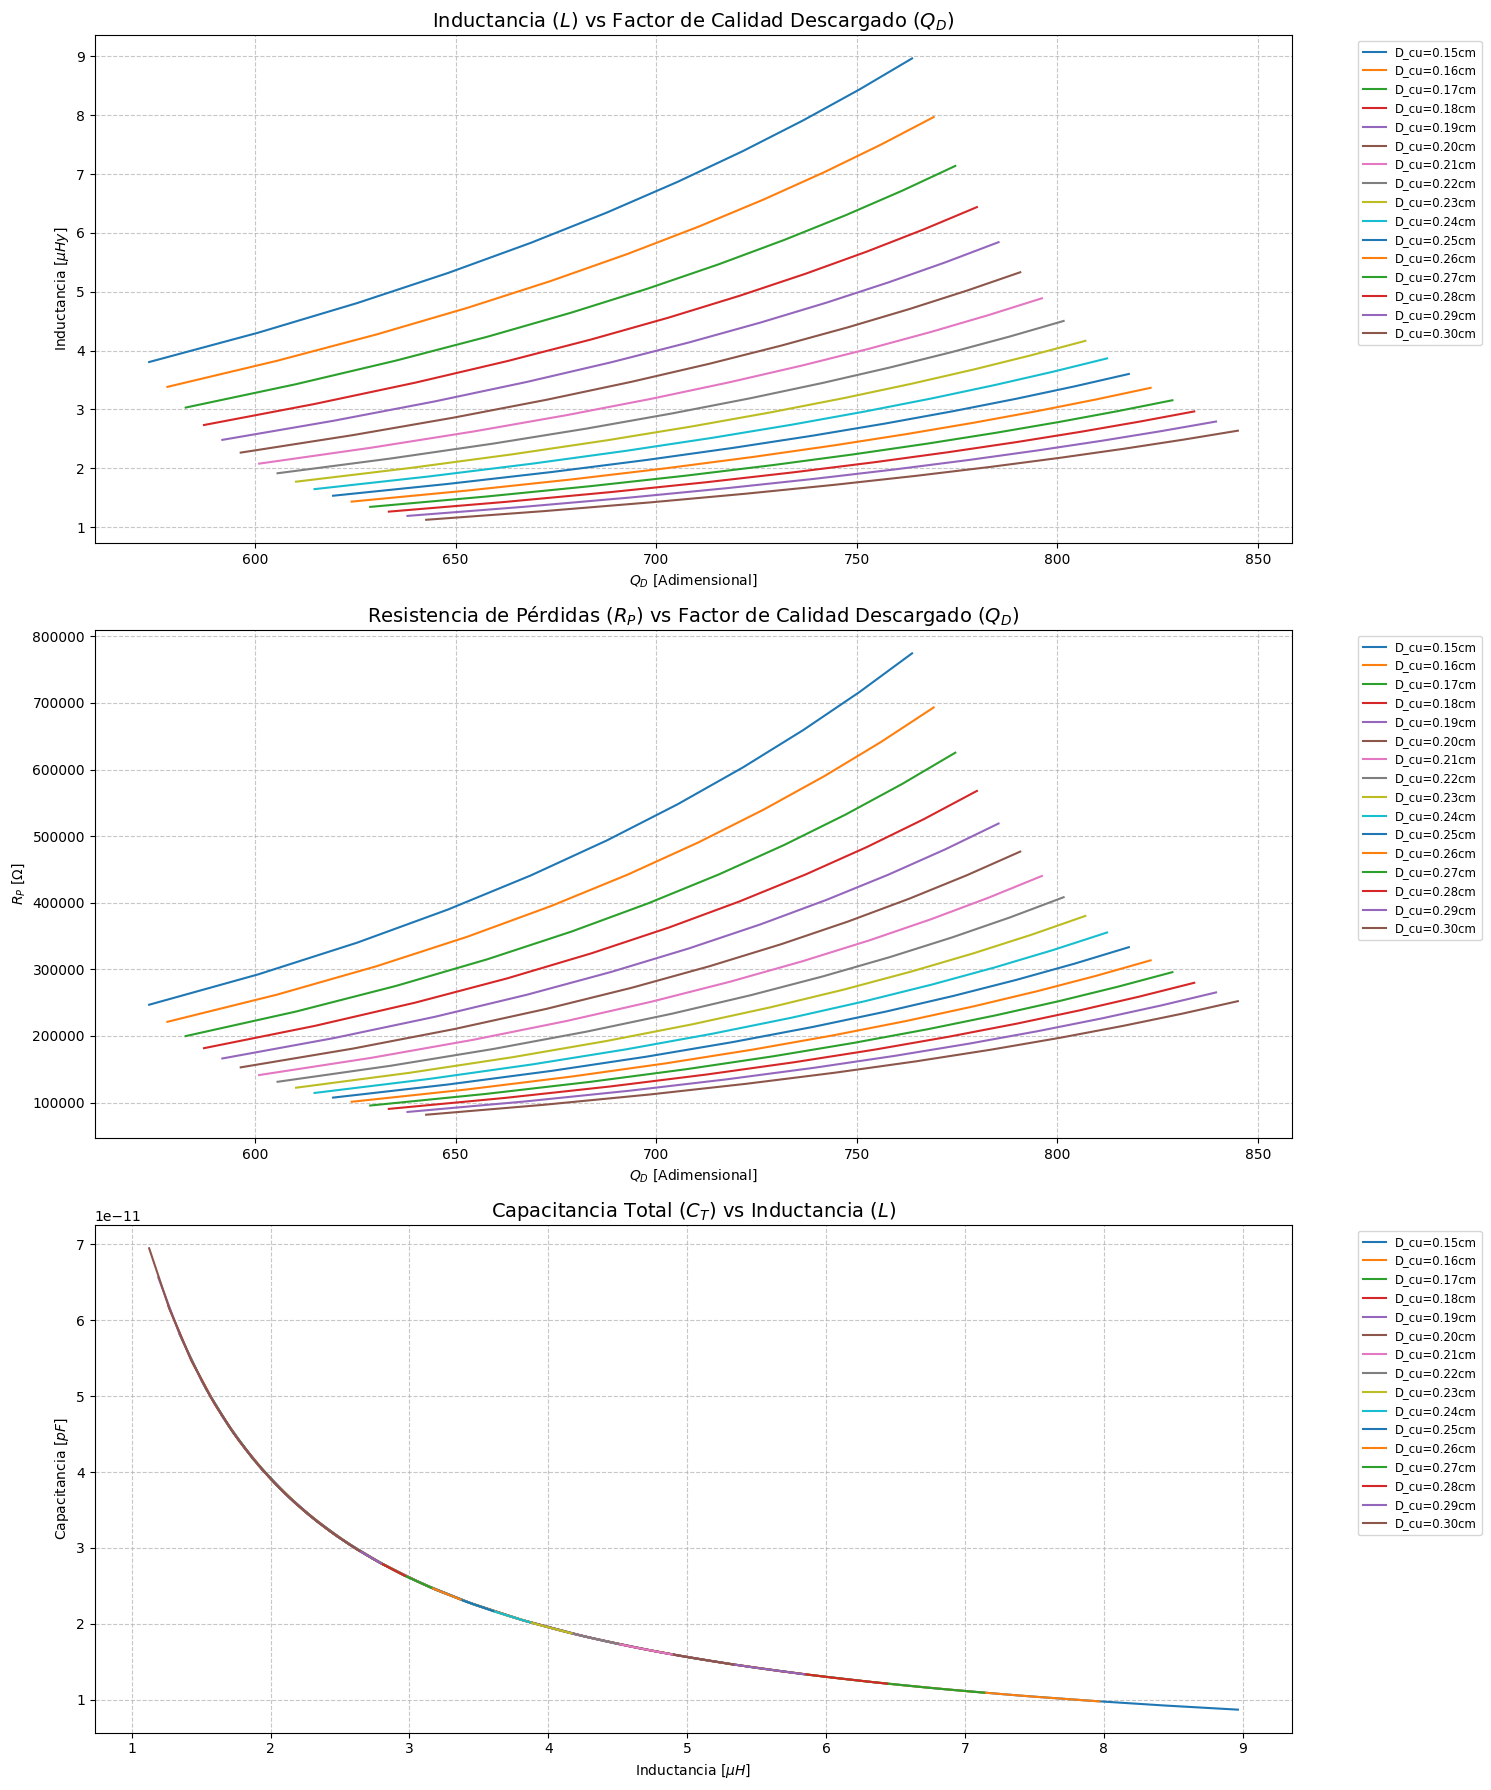

In [23]:
import matplotlib.pyplot as plt

## 8- Gráficos de Interés:
# 8.1- Se configuró el tamaño de las figuras para que sean legibles:
plt.figure(figsize=(15, 18))

# 8.2- Se realizó el primer gráfico de: Inductancia (L) - Factor de Calidad Descargado (Q_D):
plt.subplot(3, 1, 1)
for j in range(len(Diametros_cm)):
    plt.plot(Q_descargado[:, j], inductancia_uh[:, j], label=f'D_cu={Diametros_cm[j]:.2f}cm')   # Graficamos para cada diámetro (columna j)

plt.title('Inductancia ($L$) vs Factor de Calidad Descargado ($Q_D$)', fontsize=14)
plt.xlabel('$Q_D$ [Adimensional]')
plt.ylabel('Inductancia [$\mu Hy$]')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

# 8.3- Se realizo el segundo gráfico de: Resistencia de Pérdidas (R_P) - Factor de Calidad Descargado (Q_D):
plt.subplot(3, 1, 2)
for j in range(len(Diametros_cm)):
    plt.plot(Q_descargado[:, j], RP[:, j], label=f'D_cu={Diametros_cm[j]:.2f}cm')

plt.title('Resistencia de Pérdidas ($R_P$) vs Factor de Calidad Descargado ($Q_D$)', fontsize=14)
plt.xlabel('$Q_D$ [Adimensional]')
plt.ylabel('$R_P$ [$\Omega$]')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

# 8.4- Se realizo el tercer gráfico de: Capacitancia Total (C_T) - Inductancia (L):
plt.subplot(3, 1, 3)
for j in range(len(Diametros_cm)):
    plt.plot(inductancia_uh[:, j], C_total[:, j], label=f'D_cu={Diametros_cm[j]:.2f}cm')

plt.title('Capacitancia Total ($C_T$) vs Inductancia ($L$)', fontsize=14)
plt.xlabel('Inductancia [$\mu H$]')
plt.ylabel('Capacitancia [$pF$]')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

# 8.5- Se ajustó el diseño para que no se solapen las gráficas
plt.tight_layout()
plt.show()

Se necesita ahora asegurar un $BW = 10 [\%]$ de la $f_{o}$ de modo tal que por definición:

$Q_{C} = \frac{f_{o}}{BW} = \frac{R_{T}}{X_{L}}$

Por lo tanto se deduce que: $R_{T} = Q_{C} X_{L} = 2 \pi f_{o} L Q_{C}$, de modo que los posibles valores de $R_{T}$ se calculan como:

In [24]:
## 9- Calculo de la Resistencia Total:
# 9.1- Se calculó la resistencia total siguiendo la formula de arriba:
R_total = np.zeros((11,16))
for i in range(11):
  for j in range(16):
    R_total[i,j] = 2 * np.pi * f_o * (inductancia_uh[i, j] * 1e-6) * Q_cargado

# 9.2- Se armó una tabla con los valores obtenidos:
df_R_total = pd.DataFrame(R_total, index=filas_relacion, columns=columnas_diams)
print("\nTabla de la Resistencia Total (R_T) en [Ohms]")
display(df_R_total)


Tabla de la Resistencia Total (R_T) en [Ohms]


,D_cu=0.15cm,D_cu=0.16cm,D_cu=0.17cm,D_cu=0.18cm,D_cu=0.19cm,D_cu=0.20cm,D_cu=0.21cm,D_cu=0.22cm,D_cu=0.23cm,D_cu=0.24cm,D_cu=0.25cm,D_cu=0.26cm,D_cu=0.27cm,D_cu=0.28cm,D_cu=0.29cm,D_cu=0.30cm
L/D=1.0,4304.917204,3827.537061,3429.665578,3094.377266,2809.042673,2564.080338,2352.112687,2167.382965,2005.344777,1862.368160,1735.525834,1622.435527,1521.142168,1430.028814,1347.748557,1273.171944
L/D=1.1,4868.971740,4328.827314,3878.655718,3499.302700,3176.475934,2899.332544,2659.523795,2450.535214,2267.222061,2105.476697,1961.986667,1834.056277,1719.473263,1616.407993,1523.336410,1438.980526
L/D=1.2,5439.455996,4835.813330,4332.730978,3908.799553,3548.044198,3238.345723,2970.372768,2736.844208,2532.009909,2351.278928,2190.949109,2048.007649,1919.982071,1804.827559,1700.840828,1606.593617
L/D=1.3,6015.256371,5347.508004,4791.009532,4322.074593,3923.029522,3580.466476,3284.061985,3025.760868,2799.201763,2599.305767,2421.977272,2263.883316,2122.288708,1994.931383,1879.927108,1775.695909
L/D=1.4,6595.502389,5863.139871,5252.802305,4738.508073,4300.871071,3925.184474,3600.124751,3316.856476,3068.402169,2849.191070,2654.730977,2481.366217,2326.096794,2186.441660,2060.334198,1946.041512
L/D=1.5,7179.503785,6382.097263,5717.563037,5157.608767,4681.124379,4272.095330,3918.191311,3609.791410,3339.297900,3100.644863,2888.940851,2700.205321,2531.171698,2379.138495,2241.855490,2117.435847
L/D=1.6,7766.706160,6903.888979,6184.853110,5578.982292,5063.432649,4620.874466,4237.964919,3904.293144,3611.637637,3353.434516,3124.390817,2920.199285,2737.325260,2572.845564,2424.325333,2289.722923
L/D=1.7,8356.659127,7428.116016,6654.316273,6002.308366,5447.506158,4971.258348,4559.204668,4200.140456,3885.217401,3607.371235,3360.905534,3141.184744,2944.404822,2767.419827,2607.609362,2462.776224
L/D=1.8,8948.993005,7954.450907,7125.660178,6427.324187,5833.107201,5323.030781,4881.712944,4497.151899,4159.869901,3862.300202,3598.341228,3363.027757,3152.285238,2962.744035,2791.597445,2636.492062
L/D=1.9,9543.401522,8482.622376,7598.642669,6853.812087,6220.038917,5676.012737,5205.326120,4795.177246,4435.456644,4118.093259,3836.578897,3585.617470,3360.862937,3158.721161,2976.198458,2810.784649


Con todos estos valores en mente, ya podemos empezar a plantear una solución la cual partiendo de las propiedades de reflexión se tiene que:
 * $R'_{G} = R_{G}(1 + \frac{C_{2}}{C_{1}})$ ; con $R_{G} = 50 [\Omega]$
 * $R'_{L} = R_{L}(1 + \frac{C_{4}}{C_{3}})$ ; con $R_{L} = 1 [k \Omega]$

Para calcular los valores de $R'_{G}$ y de $R'_{L}$, se realizó una adaptación a la entrada, de modo que sí: $R_{T} = R'_{G}//R_{P}//R'_{L}$ entonces puedo decidir agrupar terminos a la salida, tal que: $R'_{G}//(R_{P}//R'_{L}) = 2R_{T}//2R_{T}$ y por lo tanto se deduce que:
 * $R'_{G} = 2R_{T}$
 * $R_{P}//R'_{L} = 2R_{T}$ de modo que: $R'_{L} = \frac{2R_{T}R_{P}}{R_{P} - 2R_{T}}$

Donde aquí, se tiene que tanto $R_{T}$ como $R_{P}$ se obtienen de las tablas realizadas anteriormente. Tenemos entonces, un sistema de 2 ecuaciones con 4 incógnitas ($C_{1}, C_{2}, C_{3}$ y $C_{4}$), el cual tiene infinitas soluciones que satisfacen este sistema. Por lo tanto resulta necesario introducir más ecuaciones para brindarle al sistema una solución única. Para ello utilizaremos la relación definida para los capacitores en serie, es decir:
 * $\frac{C_{T}}{2} = \frac{C_{1} C_{2}}{C_{1} + C_{2}}$
 * $\frac{C_{T}}{2} = \frac{C_{3} C_{4}}{C_{3} + C_{4}}$

Nótese aquí que con 4 incógnitas y 4 ecuaciones, el sistema tendrá una solución única.

In [25]:
## 10- Resolución final del sistema:

# 10.1- Definición de Impedancias y Rangos de Diseño
R_L = 1000  
R_G = 50 

D_HILO_MIN_MM = 2.0  
D_HILO_MAX_MM = 3.0  

VUELTAS_MIN = 10.0  

LD_MIN = 1.0        # Límite inferior para cercanía a 1
LD_MAX = 1.4        # Límite superior para cercanía a 1

disenos_validos = []
filas, columnas = R_total.shape

for i in range(filas):
    for j in range(columnas):
        # 10.2- Aplicación de Filtros de Diseño 
        # A) Filtro de Relación de Aspecto (l/D ≈ 1)
        ld_ratio = RelacionLD[i]
        if not (LD_MIN <= ld_ratio <= LD_MAX):
            continue
            
        # B) Filtro de Diámetro del cobre
        d_cu_mm = Diametros_cm[j] * 10 
        if not (D_HILO_MIN_MM <= d_cu_mm <= D_HILO_MAX_MM):
            continue
            
        # C) Filtro de número de espiras (Recomendación del profesor)
        vueltas = N[i, j]
        if vueltas < VUELTAS_MIN:
            continue

        # 10.3- Extracción de datos de las matrices
        R_T_val = R_total[i, j]
        R_p_val = RP[i, j]
        L_val = inductancia_uh[i, j]
        Q_d_val = Q_descargado[i, j]
        Ct_val_nf = C_total[i, j] * 1e9   # Conversión a [nF]

        # 10.4- Cálculo de Acople, siguiendo: C_target = C_t / 2
        C_target = C_total[i, j] / 2.0  
        
        if R_p_val <= 2.0 * R_T_val:
            continue
            
        Rg_p_target = 2.0 * R_T_val
        Rl_p_target = (2.0 * R_T_val * R_p_val) / (R_p_val - 2.0 * R_T_val)

        if (R_G > Rg_p_target) or (R_L > Rl_p_target):
            continue
            
        k_in = np.sqrt(R_G / Rg_p_target)
        k_out = np.sqrt(R_L / Rl_p_target)

        c1_p = (C_target / (1.0 - k_in)) * 1e12             # Capacitancias en pF
        c2_p = (C_target / k_in) * 1e12
        c3_p = (C_target / (1.0 - k_out)) * 1e12
        c4_p = (C_target / k_out) * 1e12

        # 10.5- Filtro valores de acuerdo al rango de los capacitores (1 - 1000 pF)
        caps = [c1_p, c2_p, c3_p, c4_p]
        if all(1.0 <= c <= 1000.0 for c in caps):
            disenos_validos.append({
                'Índice': f"[{i},{j}]",
                'L [uH]': round(L_val, 4),
                'l/D': round(ld_ratio, 2),
                'Ø_Cu [mm]': round(d_cu_mm, 2),
                'N [Vueltas]': round(vueltas, 2),
                'Q_D': round(Q_d_val, 2),
                'R_total [Ω]': round(R_T_val, 2),
                'R_P [Ω]': round(R_p_val, 2),
                'C_T [nF]': round(Ct_val_nf, 4),
                'C1 [pF]': round(c1_p, 2),
                'C2 [pF]': round(c2_p, 2),
                'C3 [pF]': round(c3_p, 2),
                'C4 [pF]': round(c4_p, 2),
                'diff_ld': abs(ld_ratio - 1.0)
            })


# 10.6- Presentación y Ordenamiento de valores
if disenos_validos:
    df_res = pd.DataFrame(disenos_validos)
    
    # Ordenamos por proximidad a l/D = 1 y luego por Q_D (mejor calidad primero)
    df_res = df_res.sort_values(by=['diff_ld', 'Q_D'], ascending=[True, False])
    
    # Reseteamos el índice: Esto crea el orden 0, 1, 2, 3... basado en el nuevo orden drop = True elimina el índice viejo, inplace = True aplica el cambio al mismo dataframe. Tambien
    # hacemos que el índice empiece en 1 en lugar de 0 para que sea un "Top".
    df_res.reset_index(drop=True, inplace=True)
    df_res.index = df_res.index + 1
    
    # Eliminamos la columna de cálculo auxiliar
    df_res = df_res.drop(columns=['diff_ld'])
    
    print(f" Se ha completado el análisis y se encontraron: {len(df_res)} combinaciones óptimas, ordenados porpor l/D ≈ 1 y Mayor Q_D")
    display(df_res)
else:
    print("No se encontraron diseños que cumplan con todos los filtros.")

 Se ha completado el análisis y se encontraron: 22 combinaciones óptimas, ordenados porpor l/D ≈ 1 y Mayor Q_D


,Índice,L [uH],l/D,Ø_Cu [mm],N [Vueltas],Q_D,R_total [Ω],R_P [Ω],C_T [nF],C1 [pF],C2 [pF],C3 [pF],C4 [pF]
1,"[1,6]",2.3515,1.1,2.1,10.21,629.05,2659.52,167298.04,0.0332,18.41,171.45,28.99,38.96
2,"[1,5]",2.5636,1.1,2.0,10.67,624.33,2899.33,181012.78,0.0305,16.81,164.21,25.78,37.32
3,"[2,8]",2.2388,1.2,2.3,10.28,664.20,2532.01,168177.08,0.0349,19.39,175.72,31.05,39.90
4,"[2,7]",2.4199,1.2,2.2,10.69,659.34,2736.84,180452.26,0.0323,17.86,169.01,27.89,38.38
5,"[2,6]",2.6264,1.2,2.1,11.14,654.49,2970.37,194408.37,0.0298,16.39,162.23,24.97,36.84
6,"[2,5]",2.8633,1.2,2.0,11.64,649.65,3238.35,210377.67,0.0273,14.97,155.38,22.26,35.29
7,"[3,11]",2.0017,1.3,2.6,10.00,702.52,2263.88,159043.33,0.0391,21.82,185.83,36.38,42.16
8,"[3,10]",2.1415,1.3,2.5,10.35,697.54,2421.98,168943.36,0.0365,20.32,179.66,33.06,40.76
9,"[3,9]",2.2983,1.3,2.4,10.72,692.57,2599.31,180019.61,0.0340,18.86,173.43,29.96,39.35
10,"[3,8]",2.4750,1.3,2.3,11.13,687.60,2799.20,192472.90,0.0316,17.44,167.12,27.06,37.92


De todas las combinaciones optimas posibles, elegiremos la primera, para la cual deberemos ajustar estos valores de capacitancias a valores comerciales de capacitores, es decir:
 * $C_{1} = 47 \ [pF] + 15 \ [pF] = 62 \ [pF] \approx 63.27 \ [pF]$
 * $C_{2} = 150 \ [pF] + 150 \ [pF] = 300 \ [pF] \approx 304.36 \ [pF]$
 * $C_{3} = 180 \ [pF] + 22 \ [pF] = 202 \ [pF] \approx 205.75 [pF]$
 * $C_{4} = 47 \ [pF] + 22 \ [pF] = 69 \ [pF] \approx 70.28 [Pf]$

Es de interés ahora, saber como debe variar el valor de la Inductancia ($L$) para una frecuencia de resonancia ($f_{o}$) de $18 \ [MHz]$ la cual es una especificación de la consigna, y para los cambios realizados en la capacitancia total ($C_{T}$) siguiendo la siguiente fórmula:

$L_{nueva} = \frac{1}{(2 \pi f_{o})^2 C_{T}} \ [uHy]$

Donde $C_{T}$ es el paralelo de dos capacitancias iguales a:
 * $C_{1}$ y $C_{2}$ en serie.
 * $C_{3}$ y $C_{4}$ en serie.

Con el nuevo valor de Inductancia, buscaremos ajustar ciertos valores constructivos del inductor tales como:
 * El Número de Espiras ($N$).
 * El Largo del Inductor ($l$).
 
Mientras dejamos fijos otros valores constructivos tales como:
 * La Separación entre Espiras ($S = d_{Cu}$).
 * El Diámetro del Cobre ($d_{Cu} = 2 [mm]$).

In [34]:
## 11- Ajuste Final por Capacitores Comerciales y Recalculo del Inductor

# 11.1- Redefino los valores de los capacitores de acuerdo a valores comerciales:
C1_com = 62     # [pF]
C2_com = 300    # [pF]
C3_com = 202    # [pF]
C4_com = 69     # [pF]

# 11.2- Defino aca los datos de la forma y el alambre que ya tengo:
Do_cm = 2.2     # Diámetro del soporte (Slide de guitarra) en cm
d_cu_mm = 2     # Diámetro del cobre elegido en mm

# 11.3- Recálculo de la Red de Capacitores (C_t nueva)
Ct_real_pf = ((C1_com * C2_com) / (C1_com + C2_com)) + ((C3_com * C4_com) / (C3_com + C4_com))
Ct_real_nf = Ct_real_pf / 1000.0    # Conversión a [nF]
Ct_real_f = Ct_real_pf * 1e-12

# 11.4- Cálculo de la Inductancia requerida para f_o = 18 MHz
L_nueva_h = 1 / ( (2 * np.pi * f_o)**2 * Ct_real_f )
L_nueva_uh = L_nueva_h * 1e6

# 11.5- Reajuste Geométrico (Cálculo de N y l)
# 1. Diámetro total (Dt) considerando el alambre
Dt_cm = Do_cm + (d_cu_mm / 10.0) 
r_cm_final = Dt_cm / 2.0

# 2. Para el cálculo de N, asumimos que queremos mantener l/D ≈ 1 (bobina óptima)
l_teorico_cm = Dt_cm  # l = D para relación 1:1
N_final = np.sqrt( (L_nueva_uh * (9 * r_cm_final + 10 * l_teorico_cm)) / (0.394 * r_cm_final**2) )

# 3. Cálculo de la longitud física real final (l)
d_cu_cm = d_cu_mm / 10.0
l_real_cm = N_final * (2 * d_cu_cm)

# 11.6- Impresión de Resultados
print(f"Capacitores fijados:")
print(f"C_1 = {C1_com} [pF]")
print(f"C_2 = {C2_com} [pF]")
print(f"C_3 = {C3_com} [pF]")
print(f"C_4 = {C4_com} [pF]")
print()
print(f"Nueva Capacitancia Total (Ct): {Ct_real_nf:.4f} [nF]") # Mostramos en nF con mayor precisión decimal
print(f"Inductancia necesaria para {f_o_mhz} MHz: {L_nueva_uh:.4f} [uH]")
print()

print("=" * 60)
print("Especificaciones Finales de la Bobina (Ajustadas):")
print(f"Número de vueltas necesario (N): {N_final:.2f} vueltas")
print(f"Longitud final de la bobina (l): {l_real_cm:.3f} cm")
print(f"Diámetro total de la bobina (Dt): {Dt_cm:.3f} cm")
print(f"Relación de aspecto final (l/D): {l_real_cm/Dt_cm:.2f}")
print("=" * 60)

Capacitores fijados:
C_1 = 62 [pF]
C_2 = 300 [pF]
C_3 = 202 [pF]
C_4 = 69 [pF]

Nueva Capacitancia Total (Ct): 0.1028 [nF]
Inductancia necesaria para 18 MHz: 0.7604 [uH]

Especificaciones Finales de la Bobina (Ajustadas):
Número de vueltas necesario (N): 6.83 vueltas
Longitud final de la bobina (l): 2.732 cm
Diámetro total de la bobina (Dt): 2.400 cm
Relación de aspecto final (l/D): 1.14
